# `multi_compartment_cable`: debug voltage compare

This notebook runs the existing `braincell` / `NEURON` single-case runners and the integrated `compare_case(...)` entry for a `multi_compartment_cable` case, then visualizes voltage traces and error statistics.


In [1]:
import importlib.util
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

os.environ.setdefault("JAX_PLATFORMS", "cpu")


def find_repo_root():
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "braincell").exists() and (candidate / "examples").exists():
            return candidate
    raise RuntimeError("Run this notebook from the repository root or a subdirectory inside it.")


def load_module(path: Path, name: str):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    assert spec is not None and spec.loader is not None
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module


repo_root = find_repo_root()
templates_root = repo_root / "examples" / "neuron_compare" / "templates"
cable_root = templates_root / "multi_compartment_cable"

for path in (repo_root, templates_root, cable_root):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

case_schema = load_module(cable_root / "case_schema.py", "mc_cable_case_schema_nb")
braincell_single_case = load_module(cable_root / "braincell_single_case.py", "mc_cable_braincell_runner_nb")
neuron_single_case = load_module(cable_root / "neuron_single_case.py", "mc_cable_neuron_runner_nb")
compare_multi_compartment_cable = load_module(
    templates_root / "compare_multi_compartment_cable.py",
    "mc_cable_compare_entry_nb",
)

print("repo_root:", repo_root)


ERROR:2026-04-16 14:01:20,488:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 257, in _check_cuda_versions
    cublas_version = _version_check("cuBLAS", cuda_versions.cublas_get_version,
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 217, in _version_check
    raise RuntimeError(msg)
RuntimeError: Outdated cuBLAS installation found.
Version JAX was built against: 12

repo_root: /home/swl/braincell


In [2]:
case_path = repo_root / "examples" / "neuron_compare" / "cases" / "multi_compartment_cable.example.json"
case = compare_multi_compartment_cable.load_case(case_path)

print("case_path:", case_path)
print("case_id:", case.case_id)
print("swc:", case.swc.path)
print("cv_policy:", case.cv_policy.kind, case.cv_policy.cv_per_branch)
print("stimulus kind:", case.stimulus.kind)
print("dt_ms:", case.simulation.dt_ms)
print("duration_ms:", case.simulation.duration_ms)


case_path: /home/swl/braincell/examples/neuron_compare/cases/multi_compartment_cable.example.json
case_id: unbranched_soma_dc_smoke
swc: /home/swl/braincell/examples/multi_compartment/morpho_files/io.swc
cv_policy: CVPerBranch 3
stimulus kind: dc_step
dt_ms: 0.01
duration_ms: 5.0


In [3]:
braincell_result = braincell_single_case.run_case(case)
neuron_result = neuron_single_case.run_case(case)
compare_result = compare_multi_compartment_cable.compare_case(case)

time_ms = np.asarray(compare_result["time_ms"], dtype=float)
braincell_voltage = np.asarray(compare_result["braincell"]["voltage_mV"], dtype=float)
neuron_voltage = np.asarray(compare_result["neuron"]["voltage_mV"], dtype=float)
abs_error = np.abs(braincell_voltage - neuron_voltage)

print("braincell voltage shape:", braincell_voltage.shape)
print("neuron voltage shape:", neuron_voltage.shape)
print("overall metrics:")
print(json.dumps(compare_result["metrics"]["overall"], indent=2, sort_keys=True))


--No graphics will be displayed.


braincell voltage shape: (500, 93)
neuron voltage shape: (500, 93)
overall metrics:
{
  "mae": 1.7575142481423575e-09,
  "max_abs": 1.399776294874755e-08,
  "rel_mae_pct": 2.7185144643843455e-09,
  "rmse": 2.413158374260837e-09
}


In [4]:
alignment = compare_result["alignment"]
branch_pairs_df = pd.DataFrame(alignment["branch_pairs"])
compartment_pairs_df = pd.DataFrame(alignment["compartment_pairs"])
stimulus_target_pair = alignment["stimulus_target_pair"]
sum_error_mV = (braincell_voltage.sum(axis=1) - neuron_voltage.sum(axis=1))

print("stimulus_target_pair:")
print(json.dumps(stimulus_target_pair, indent=2, sort_keys=True))
print("branch_pairs:")
display(branch_pairs_df)
print("sum error stats (mV):")
print({
    "mean_abs": float(np.mean(np.abs(sum_error_mV))),
    "max_abs": float(np.max(np.abs(sum_error_mV))),
})


stimulus_target_pair:
{
  "braincell_branch_id": 0,
  "braincell_branch_name": "soma",
  "braincell_canonical_name": "soma[0]",
  "braincell_compartment_index": 1,
  "local_index": 1,
  "neuron_canonical_name": "soma[0]",
  "neuron_compartment_index": 1,
  "neuron_section_index": 0,
  "neuron_section_name": "soma[0]"
}
branch_pairs:


,braincell_branch_id,braincell_branch_name,braincell_canonical_name,braincell_branch_type,neuron_section_index,neuron_section_name,neuron_canonical_name,neuron_section_type,match_score,length_diff_um,subtree_total_length_diff_um,parent_attach_diff,child_attach_diff,subtree_signature
0,0,soma,soma[0],soma,0,soma[0],soma[0],soma,0.000040,0.000000e+00,2.000000e-05,0.0,0.0,"[soma, 7.645242, 2601.704316, 17, 5, [basal_de..."
1,1,soma_0,soma[1],soma,1,soma[1],soma[1],soma,0.000026,0.000000e+00,1.300000e-05,0.0,0.0,"[soma, 12.238614, 476.562246, 3, 2, [basal_den..."
2,2,soma_1,soma[2],soma,2,soma[2],soma[2],soma,0.000012,1.000000e-06,1.000000e-06,0.0,0.0,"[soma, 12.075303, 12.075303, 1, 0, [], []]"
3,3,soma_2,soma[3],soma,3,soma[3],soma[3],soma,0.000008,0.000000e+00,4.000000e-06,0.0,0.0,"[soma, 12.062896, 283.966686, 1, 1, [basal_den..."
4,4,soma_3,soma[4],soma,4,soma[4],soma[4],soma,0.000018,1.000000e-06,4.000000e-06,0.0,0.0,"[soma, 11.57658, 224.886571, 1, 1, [basal_dend..."
5,5,soma_4,soma[5],soma,5,soma[5],soma[5],soma,0.000012,0.000000e+00,6.000000e-06,0.0,0.0,"[soma, 11.454256, 670.078464, 5, 4, [basal_den..."
6,6,basal_dendrite_0,dend[0],basal_dendrite,6,dend[0],dend[0],basal_dendrite,0.000004,0.000000e+00,2.000000e-06,0.0,0.0,"[basal_dendrite, 3.242811, 926.489804, 6, 3, [..."
7,7,basal_dendrite_1,dend[1],basal_dendrite,7,dend[1],dend[1],basal_dendrite,0.000010,0.000000e+00,5.000000e-06,0.0,0.0,"[basal_dendrite, 10.659377, 648.779781, 3, 2, ..."
8,8,basal_dendrite_2,dend[2],basal_dendrite,8,dend[2],dend[2],basal_dendrite,0.000072,6.000000e-06,6.000000e-06,0.0,0.0,"[basal_dendrite, 219.305944, 219.305944, 1, 0,..."
9,9,basal_dendrite_3,dend[3],basal_dendrite,9,dend[3],dend[3],basal_dendrite,0.000072,5.000000e-06,1.100000e-05,0.0,0.0,"[basal_dendrite, 91.70962, 418.81446, 2, 1, [b..."


sum error stats (mV):
{'mean_abs': 1.1215058839297854e-07, 'max_abs': 1.7104684957303107e-07}


In [5]:
braincell_labels = compare_result["alignment"]["braincell_labels"]
neuron_labels = compare_result["alignment"]["neuron_labels"]


def short_braincell_label(label):
    return label.get('canonical_label', f"bc:b{label['branch_id']}-cv{label['local_index']}")


def short_neuron_label(label):
    return label.get('canonical_label', f"nrn:s{label['section_index']}-seg{label['local_index']}")


def overlay_label(index):
    return f"{short_braincell_label(braincell_labels[index])} / {short_neuron_label(neuron_labels[index])}"


n_compartment = braincell_voltage.shape[1]
overlay_indices = list(range(min(3, n_compartment)))


/tmp/ipykernel_3207987/1769409046.py:35: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(rect=(0.0, 0.0, 0.82, 1.0))


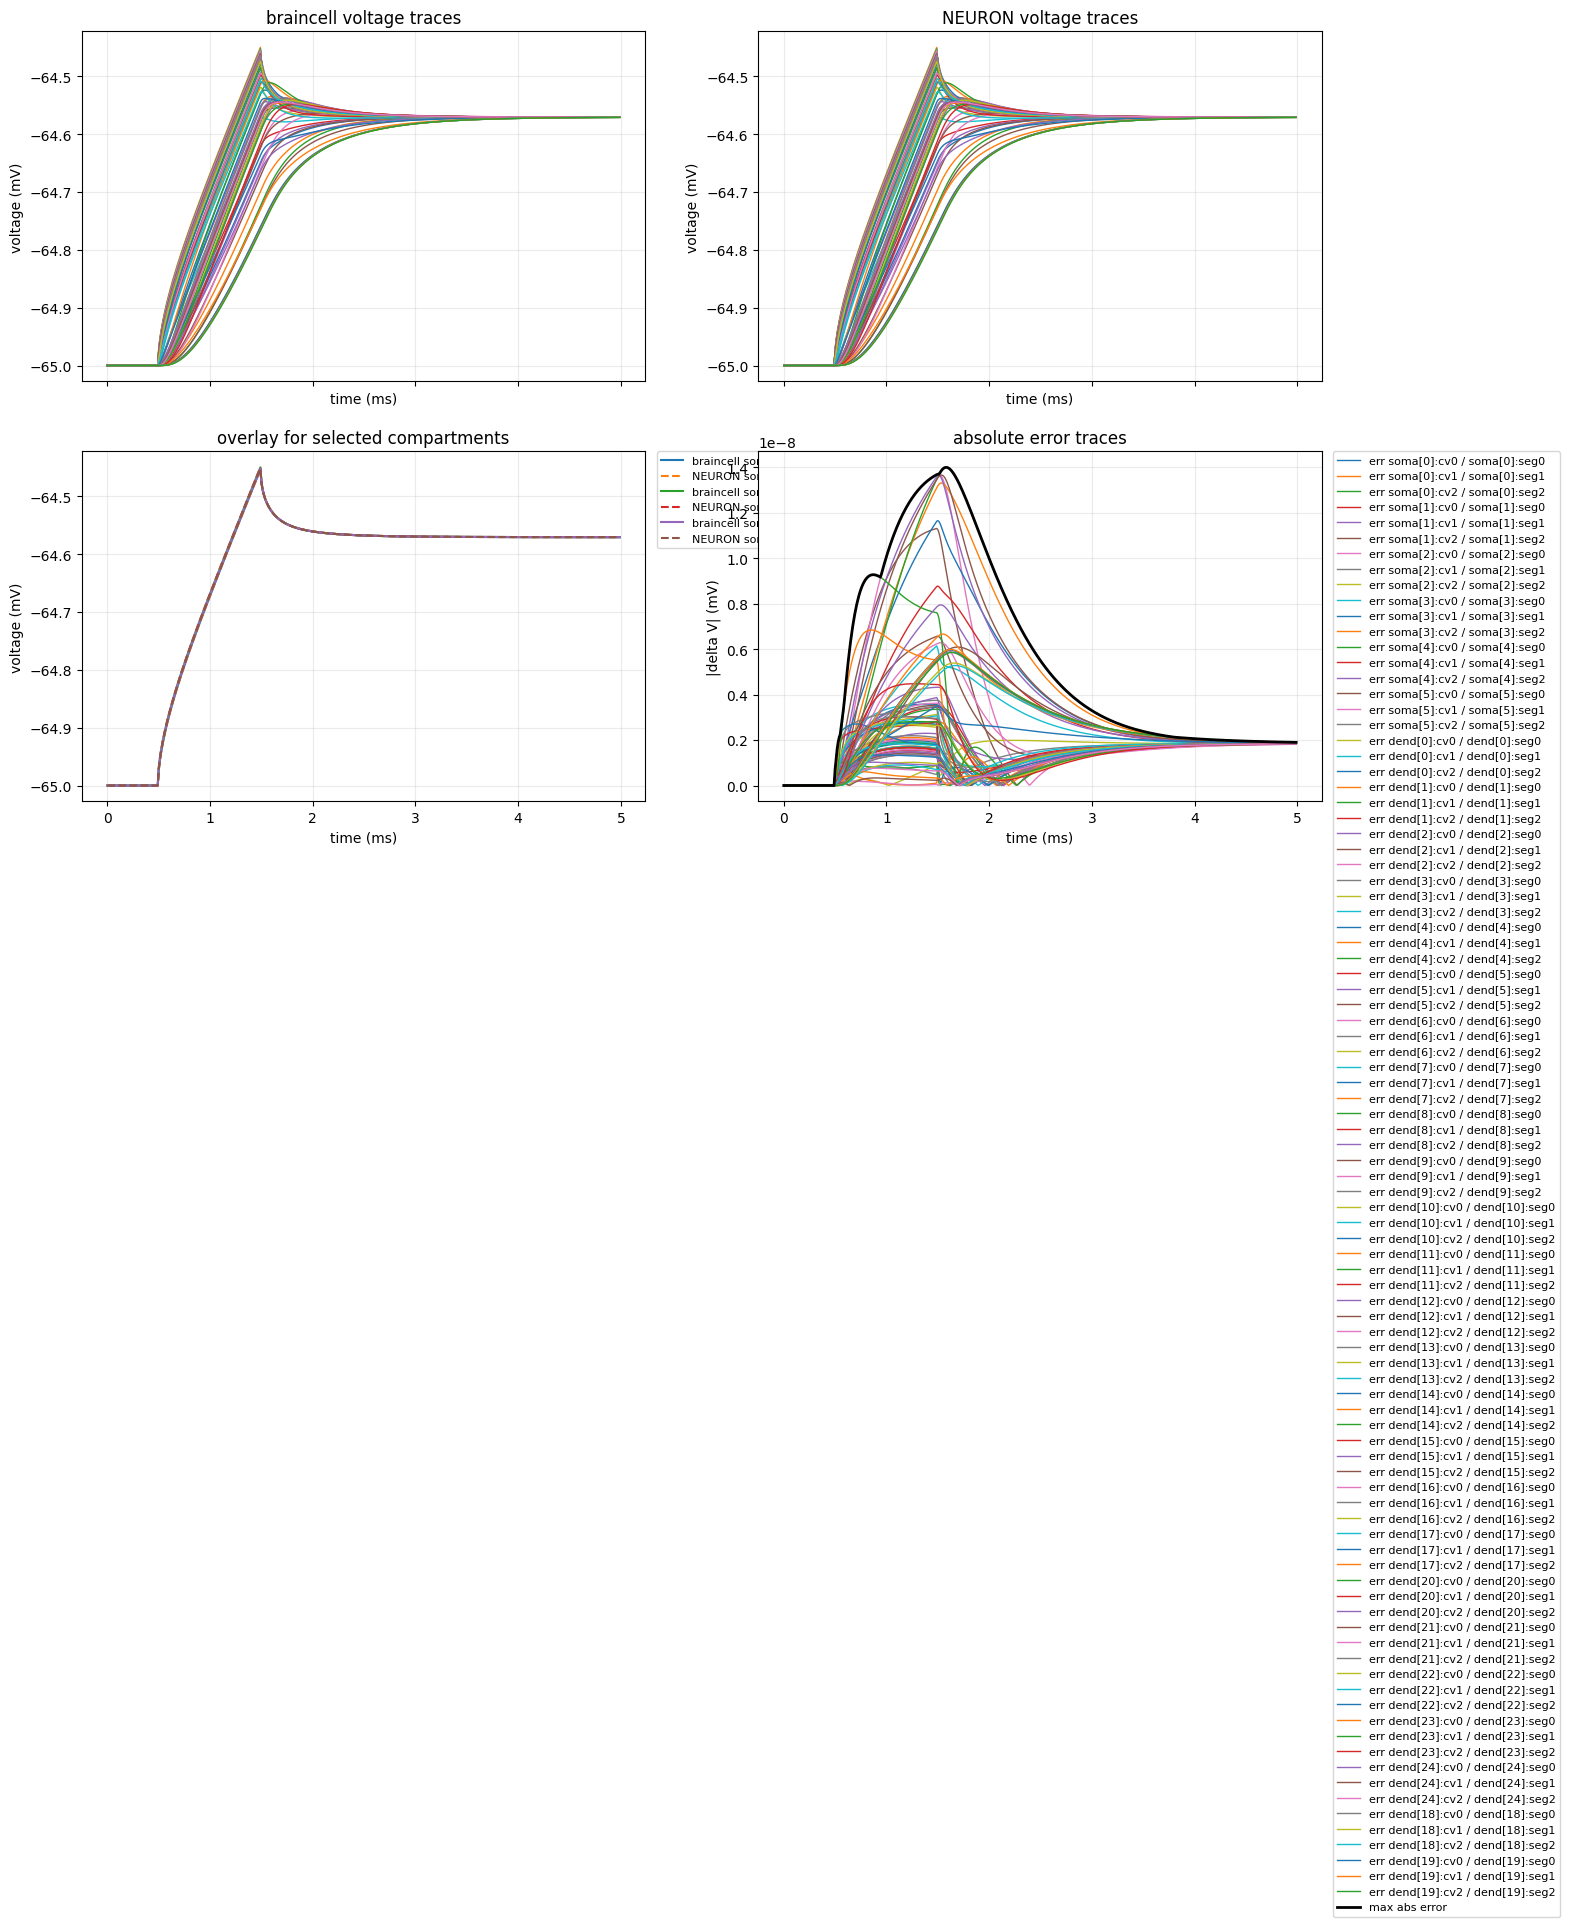

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex='col', gridspec_kw={'width_ratios': [1, 1]})

for index in range(n_compartment):
    axes[0, 0].plot(time_ms, braincell_voltage[:, index], linewidth=1.0, label=short_braincell_label(braincell_labels[index]))
axes[0, 0].set_title("braincell voltage traces")
axes[0, 0].set_xlabel("time (ms)")
axes[0, 0].set_ylabel("voltage (mV)")
axes[0, 0].grid(alpha=0.25)

for index in range(n_compartment):
    axes[0, 1].plot(time_ms, neuron_voltage[:, index], linewidth=1.0, label=short_neuron_label(neuron_labels[index]))
axes[0, 1].set_title("NEURON voltage traces")
axes[0, 1].set_xlabel("time (ms)")
axes[0, 1].set_ylabel("voltage (mV)")
axes[0, 1].grid(alpha=0.25)

for index in overlay_indices:
    axes[1, 0].plot(time_ms, braincell_voltage[:, index], linewidth=1.5, label=f"braincell {overlay_label(index)}")
    axes[1, 0].plot(time_ms, neuron_voltage[:, index], linestyle="--", linewidth=1.5, label=f"NEURON {overlay_label(index)}")
axes[1, 0].set_title("overlay for selected compartments")
axes[1, 0].set_xlabel("time (ms)")
axes[1, 0].set_ylabel("voltage (mV)")
axes[1, 0].grid(alpha=0.25)
axes[1, 0].legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)

for index in range(n_compartment):
    axes[1, 1].plot(time_ms, abs_error[:, index], linewidth=1.0, label=f"err {overlay_label(index)}")
axes[1, 1].plot(time_ms, abs_error.max(axis=1), color="black", linewidth=2.0, label="max abs error")
axes[1, 1].set_title("absolute error traces")
axes[1, 1].set_xlabel("time (ms)")
axes[1, 1].set_ylabel("|delta V| (mV)")
axes[1, 1].grid(alpha=0.25)
axes[1, 1].legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)

fig.tight_layout(rect=(0.0, 0.0, 0.82, 1.0))
plt.show()


In [7]:
per_compartment_df = pd.DataFrame(compare_result["metrics"]["per_compartment"])
per_compartment_df["braincell_label"] = [short_braincell_label(label) for label in braincell_labels]
per_compartment_df["neuron_label"] = [short_neuron_label(label) for label in neuron_labels]
per_compartment_df = per_compartment_df.sort_values(["mae", "max_abs"], ascending=False)
per_compartment_df


,compartment_index,mae,rmse,max_abs,rel_mae_pct,braincell_label,neuron_label
32,32,4.667900e-09,6.215143e-09,1.399776e-08,7.215946e-09,dend[4]:cv2,dend[4]:seg2
31,31,4.479190e-09,5.900158e-09,1.330837e-08,6.924808e-09,dend[4]:cv1,dend[4]:seg1
35,35,4.346361e-09,5.815085e-09,1.365734e-08,6.720082e-09,dend[5]:cv2,dend[5]:seg2
34,34,4.319704e-09,5.758528e-09,1.365569e-08,6.679305e-09,dend[5]:cv1,dend[5]:seg1
30,30,3.965806e-09,5.092424e-09,1.165279e-08,6.132136e-09,dend[4]:cv0,dend[4]:seg0
...,...,...,...,...,...,...,...
86,86,1.030805e-09,1.220335e-09,1.828568e-09,1.594295e-09,dend[24]:cv2,dend[24]:seg2
51,51,1.024653e-09,1.264685e-09,1.832660e-09,1.585301e-09,dend[11]:cv0,dend[11]:seg0
81,81,9.969236e-10,1.202963e-09,1.828610e-09,1.541915e-09,dend[23]:cv0,dend[23]:seg0
85,85,9.522523e-10,1.190887e-09,1.828724e-09,1.472829e-09,dend[24]:cv1,dend[24]:seg1
